# Preprocessing data
In this notebook, we will prepare data from a file called `florida_weather_data_preprocess.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

## Step 1: load data using the pandas library
Here we want to read the file form the file path, and then inspect the dataframe.

In [8]:
file_path = '../data/florida_weather_data_preprocess.csv'
df_weather = pd.read_csv(file_path, index_col=0)
df_weather

,Navn,Stasjon,Tid(norsk normaltid),Nedbør (1 t),Maksimumstemperatur (1 t),Minimumstemperatur (1 t),Middelvind,Høyeste middelvind (1 t)
35000,Bergen - Florida,SN50540,28.12.2024 09:00,1.9,7.9,7.7,4.6,5.5
35001,Bergen - Florida,SN50540,28.12.2024 10:00,2.9,8.4,7.9,4.1,5.1
35002,Bergen - Florida,SN50540,28.12.2024 11:00,3.2,8.5,8.4,3.7,4.2
35003,Bergen - Florida,SN50540,28.12.2024 12:00,2.1,8.4,8.4,4.4,4.4
35004,Bergen - Florida,SN50540,28.12.2024 13:00,-1.5,8.5,8.4,4.3,4.6
...,...,...,...,...,...,...,...,...
41331,Bergen - Florida,SN50540,18.09.2025 04:00,0.0,13.2,12.8,5.5,5.5
41332,Bergen - Florida,SN50540,18.09.2025 05:00,0.0,13.4,12.9,4.7,6.6
41333,Bergen - Florida,SN50540,18.09.2025 06:00,1.3,12.8,11.9,6.7,7.1
41334,Bergen - Florida,SN50540,18.09.2025 07:00,1.3,13.1,12.2,6.1,8.9


## Step 2: quality control
For quality control, we must first look at the data. The easiest way to spot problems is usually to plot the data and look for problem areas.
We first extract the data we need.

In [9]:
df_weather_extract = df_weather.iloc[:,3:].sort_index().astype(float)
df_weather_extract.columns = ['Pr','Tmax','Tmin','w_mean','w_max']

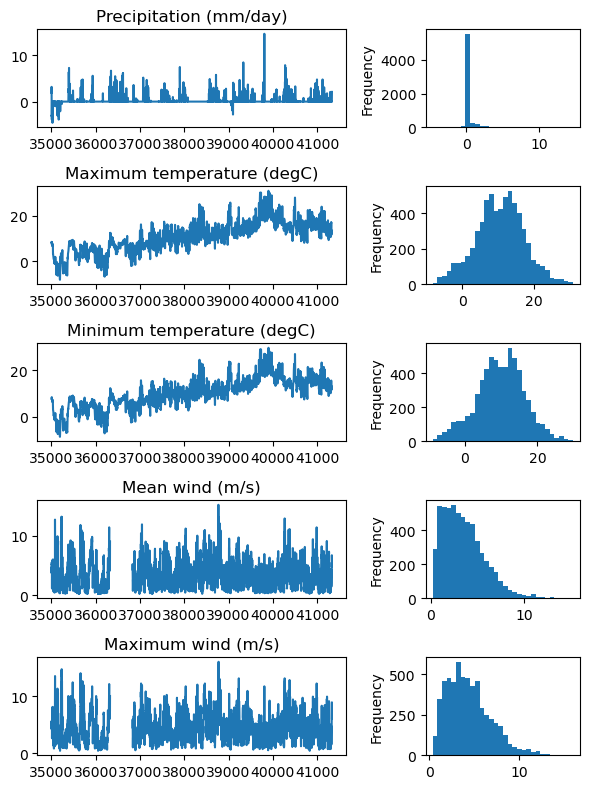

In [10]:
## Here we create a set of plots to look at a subset of our dataframe, selected into the dataset [df_weather_extract]
fig, axs = plt.subplots(5,2,figsize=(6,8), width_ratios=[2,1])

df_weather_extract.Pr.plot(ax=axs[0,0])
df_weather_extract.Tmax.plot(ax=axs[1,0])
df_weather_extract.Tmin.plot(ax=axs[2,0])
df_weather_extract.w_mean.plot(ax=axs[3,0])
df_weather_extract.w_max.plot(ax=axs[4,0])

df_weather_extract.Pr.plot.hist(ax=axs[0,1], bins=30)
df_weather_extract.Tmax.plot.hist(ax=axs[1,1], bins=30)
df_weather_extract.Tmin.plot.hist(ax=axs[2,1], bins=30)
df_weather_extract.w_mean.plot.hist(ax=axs[3,1], bins=30)
df_weather_extract.w_max.plot.hist(ax=axs[4,1], bins=30)

axs[0,0].set_title('Precipitation (mm/day)')
axs[1,0].set_title('Maximum temperature (degC)')
axs[2,0].set_title('Minimum temperature (degC)')
axs[3,0].set_title('Mean wind (m/s)')
axs[4,0].set_title('Maximum wind (m/s)')

plt.tight_layout()

### Issues?

### Only select data with good quality
Here we filter out missing data in four of our variables, and remove nonsensical data from a third.

In [ ]:
qc_data_index = (df_weather_extract.w_max.notnull() &
                 df_weather_extract.w_mean.notnull()&
                 df_weather_extract.Tmin.notnull()&
                 df_weather_extract.Tmax.notnull()&
                 (df_weather_extract.Pr >= 0 ) )
df_weather_extract_qc = df_weather_extract.loc[qc_data_index]

## **QUESTION 1**: Compare the two datafames: `df_weather_extract_qc` and `df_weather_extract`
How can we compare the original dataset and our new, augmented one? How much data are we left with?

In [ ]:
print(...)
print(...)

## Step 3: Reshaping the data
Up to this point, we have explored and 'cleaned' the data to make it better suited for analysis. 
The next step is to choose what we want to predict, our model output, and what we want to predict it based on, our features. 
In this example, we'll try to predict the precipitation based on the other selected variables above.

## **QUESTION 2**: Extract the variables wanted into `X` and `y` arrays

We want to predict mean wind based on the other variables.

In [ ]:
X = df_weather_extract_qc[[]].values ## In the inner brackets, select the features we want
y = df_weather_extract_qc[].values ## In these brackets, select the desired output
print(X.shape, y.shape)

Both `X` and `y` arrays should be in the shape `(n_samples, n_variables_per_sample)`. Is it the case?

## **QUESTION 3**: Reshape `X` and `y` arrays

In [ ]:
y = ...

## Step 4: Split into train, validation test



## **QUESTION 4**: Create train, validation and test datasets from `X`

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

## Step 5: Tranforming the data
The next step is to standardise the data into a shape our ML-algoritm understands.

In [ ]:
## First, we import the standardisation functions we want from Scikit-learn
from sklearn.preprocessing import StandardScaler, PowerTransformer, Binarizer

## This next line lets us apply different transformation to each column
from sklearn.compose import ColumnTransformer 

### X Transform
Here, we use two transformers, `Standardize` on our temperature and precipitation variables, and `Power transform` on our wind variables.

In [ ]:
preprocessor_X = ColumnTransformer(
    transformers=[('Standardize', StandardScaler(), [0,1]),
                  ('Power transform', PowerTransformer(standardize=True), [2,3]),
                  ])

preprocessor_X

## **QUESTION 5**: Fit the `preprocessor_X` to the train dataset and transform the three `X` datasets

In [ ]:
...

X_train_transform = ...
X_val_transform = ...
X_test_transform = ...

### y Transform
Here we use the transformer `PowerTransformer` on our predicted wind data.

In [ ]:
preprocessor_y = PowerTransformer()

preprocessor_y

## **QUESTION 6**: Fit the `preprocessor_y` to the train dataset and transform the three `y` datasets

In [ ]:
...

y_train_transform = ...
y_val_transform = ...
y_test_transform = ...

### Plot the transformed dat

In [ ]:
## Now we plot our newly transformed data!

fig, axs = plt.subplots(5,2,figsize=(6,8), width_ratios=[2,1])

axs[0,0].plot(X_train_transform[:,0])
axs[1,0].plot(X_train_transform[:,1])
axs[2,0].plot(X_train_transform[:,2])
axs[3,0].plot(X_train_transform[:,3])
axs[4,0].plot(y_train_transform[:,0], color='C3')

axs[0,1].hist(X_train_transform[:,0])
axs[1,1].hist(X_train_transform[:,1])
axs[2,1].hist(X_train_transform[:,2])
axs[3,1].hist(X_train_transform[:,3])
axs[4,1].hist(y_train_transform[:,0], color='C3')


axs[4,0].set_title('Mean wind (m/s)')
axs[0,0].set_title('Maximum temperature (degC)')
axs[1,0].set_title('Minimum temperature (degC)')
axs[2,0].set_title('Precipitation (mm/day)')
axs[3,0].set_title('Maximum wind (m/s)')

plt.tight_layout()

## Step 6: Design an ML model and make a prediction
We use the transformed data to make a prediction

### Define model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_transform, y_train_transform)

### Make predctions on validation

In [ ]:
y_val_transform_predict = model.predict(X_val_transform)

## Step 7: Return data to original dataspace for evaluation
If we don't do this, it is impossible to compare the impact of different transformation.

## **QUESTION 7**: Return `y_val_transform_predict` into the original `y` dataspace by using `inverse_transform`

In [ ]:
y_val_predict = ...

## Step 8: Evaluate model

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val, y_val_predict, s=5, color='.5')
ax.grid()
ax.set_ylabel('Mean wind Predictions (m/s)')
ax.set_xlabel('Mean wind Truths (m/s)')
ax.axline((0,0), slope=1, color='tab:red', ls='--')
r2 = sklearn.metrics.r2_score(y_val,y_val_predict)
ax.set_title(f"R2 = {r2:.02f}")
